In [18]:
from google.colab import files
uploaded=files.upload()

Saving heart (1).csv to heart (1) (1).csv


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv("heart (1).csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:


df = df.dropna()
df = df.drop_duplicates()
df.columns = df.columns.str.lower().str.strip()
df = df[df["age"] > 0]

In [22]:
df["target"] = df["target"].replace({0: 1, 1: 0})
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,1
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,1
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,1
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,1


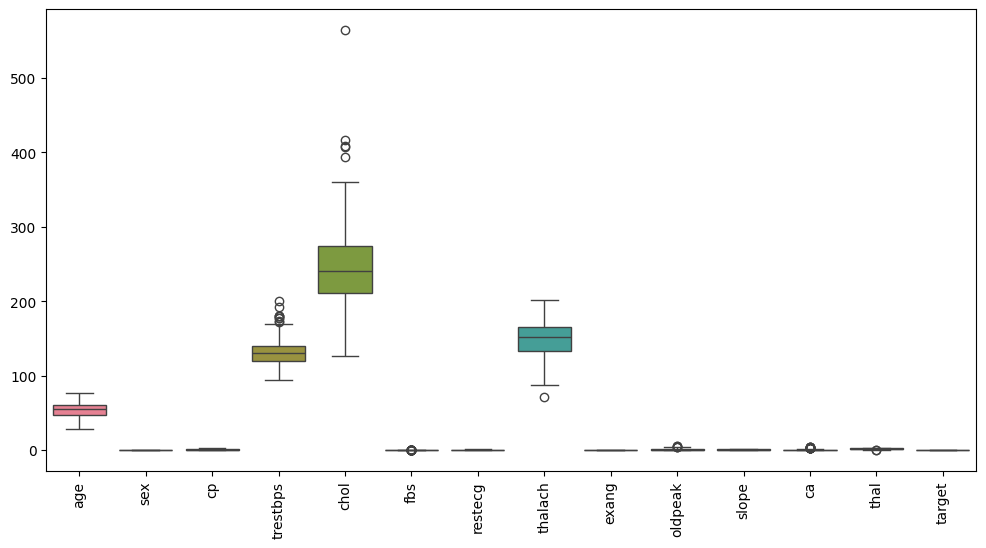

In [23]:

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [24]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [25]:
 df.corr()["target"].sort_values(ascending=False)

,target
target,1.000000
exang,0.435601
oldpeak,0.429146
ca,0.408992
thal,0.343101
sex,0.283609
age,0.221476
trestbps,0.146269
chol,0.081437
fbs,0.026826


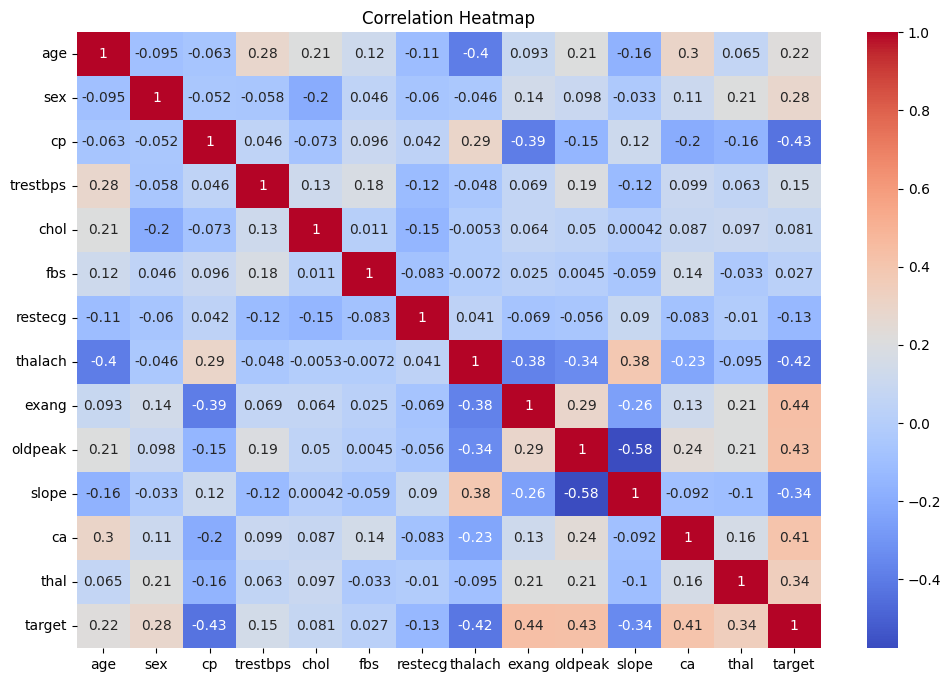

In [26]:


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

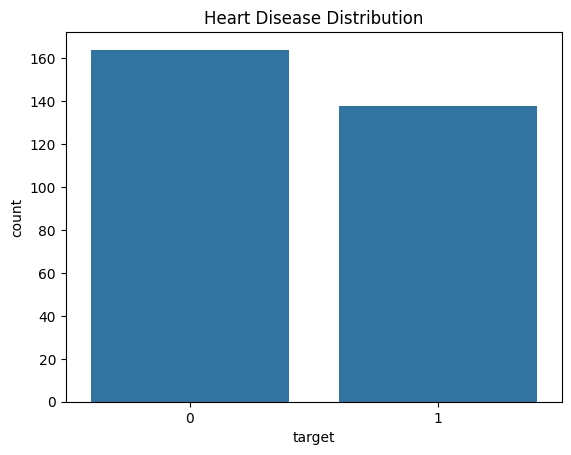

In [27]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [28]:

cp_analysis = df.groupby("cp")["target"].mean() * 100
print(cp_analysis)

cp
0    72.727273
1    18.000000
2    20.930233
3    30.434783
Name: target, dtype: float64


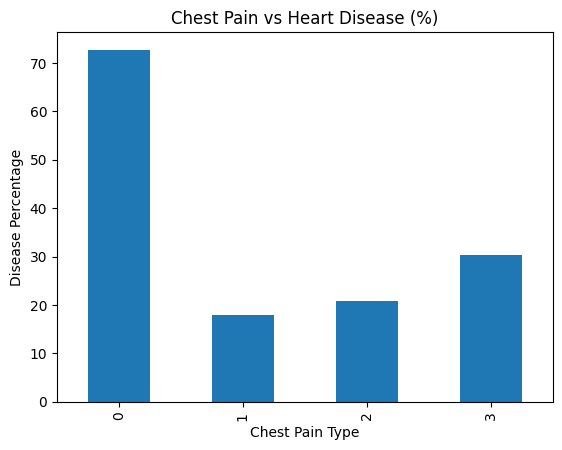

In [29]:
cp_analysis.plot(kind="bar")
plt.title("Chest Pain vs Heart Disease (%)")
plt.xlabel("Chest Pain Type")
plt.ylabel("Disease Percentage")
plt.savefig("cp_analysis.png")
plt.show()

In [30]:
oldpeak_analysis=df.groupby("target")["oldpeak"].mean()

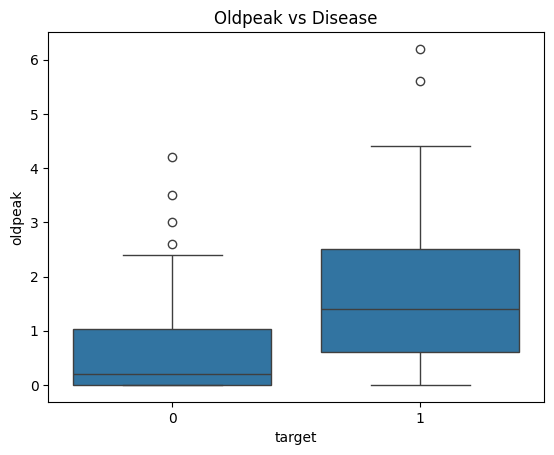

In [31]:
oldpeak_analysis=sns.boxplot(x="target", y="oldpeak", data=df)
plt.title("Oldpeak vs Disease")
plt.savefig("oldpeak_analysis.png")
plt.show()

In [32]:
exang_analysis=df.groupby("exang")["target"].mean() * 100

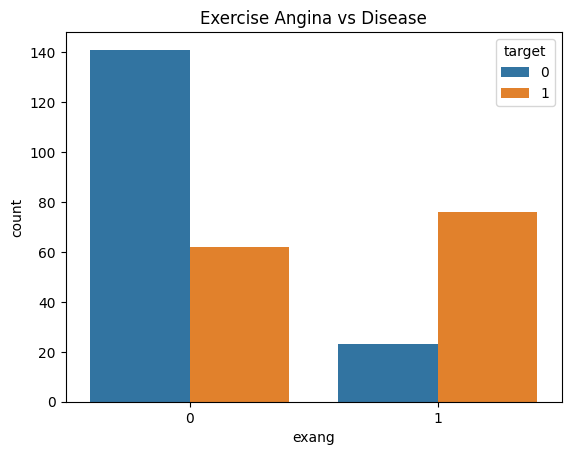

In [33]:
exang_analysis=sns.countplot(x="exang", hue="target", data=df)
plt.title("Exercise Angina vs Disease")
plt.savefig("exang_analysis.png")
plt.show()

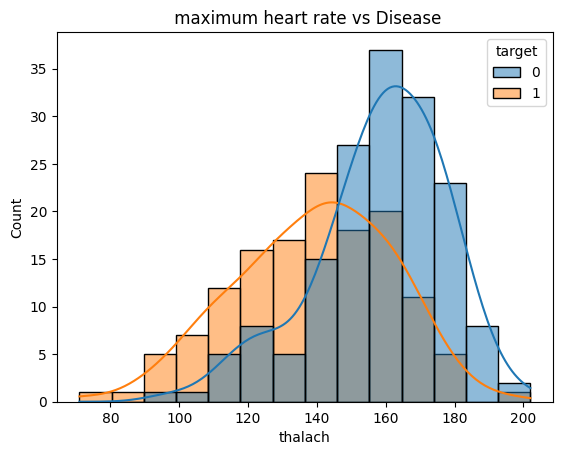

In [34]:
thalach_analysis=sns.histplot(data=df, x="thalach", hue="target", kde=True)
plt.title(" maximum heart rate vs Disease")
plt.savefig("thalach_analysis.png")
plt.show()

In [35]:
gender_analysis=df.groupby("sex")["target"].mean()

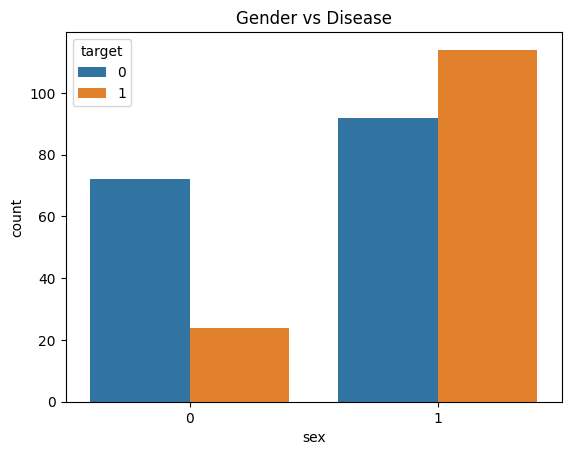

In [36]:
gender_analysis=sns.countplot(x="sex", hue="target", data=df)
plt.title("Gender vs Disease")
plt.savefig("gender_analysis.png")
plt.show()

In [37]:
df["age_group"] = pd.cut(df["age"],
                        bins=[20,30,40,50,60,70,80],
                        labels=["20-30","30-40","40-50","50-60","60-70","70-80"])



In [38]:
df["age_group"].value_counts().sort_values(ascending=False)

,count
age_group,
50-60,129
40-50,76
60-70,73
30-40,17
70-80,6
20-30,1


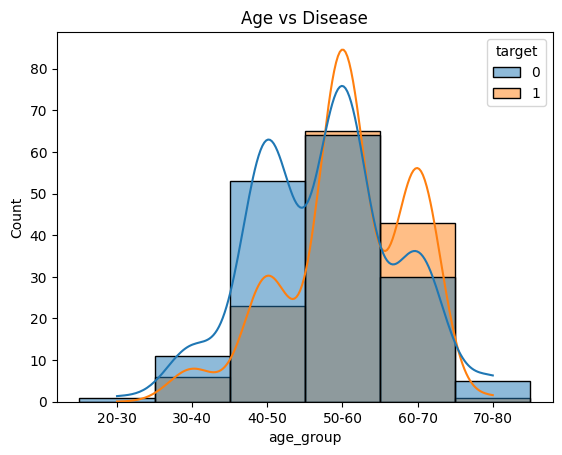

In [39]:
age_group_analysis=sns.histplot(data=df, x="age_group", hue="target", kde=True)
plt.title("Age vs Disease")
plt.savefig("age_group_analysis.png")
plt.show()